In [1]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients, NoiseTunnel

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
import xarray as xr
from tqdm import tqdm
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import argparse

import sys 
import seaborn as sns
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')

from ml_module_rain.models.trained_models import load_trained_model

Running imports...


In [2]:
run_id = 'dfkp0m9h'
samples_to_attribute = 'TP'
dataloader, lightning_model = load_trained_model(run_id)
lightning_model.eval()
lightning_model.model.eval()
all_targets = []
all_probas = []
for batch in tqdm(dataloader.val_loader):
    x, y = batch
    lightning_model.eval()
    with torch.no_grad():
        all_probas.append(lightning_model(x))
    all_targets.append(y)
probas = torch.cat(all_probas).view(-1, 4, 3)
targets = torch.cat(all_targets).cpu().numpy()
preds = torch.argmax(probas, dim=2).cpu().numpy() 
probas = probas.cpu().numpy()

ds_aligned = dataloader.ds_val.isel(time=range(targets.shape[0]))
preds_da = xr.DataArray(preds, dims=['time','timestep'], coords =ds_aligned.targets.coords)
# probas_da = xr.DataArray(probas, dims=['time','timestep'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da


Data ready:
    Image size: 16380 (182x90)
    Input variables: u850
    21732 samples in train
    4657 samples in validation
    4658 samples in test
    4 Predicted timesteps for future rainfall
    Prediction type: three_classes_grey_zone
    What quantile is considered extreme: 90th of rainy days


100%|██████████| 9/9 [00:11<00:00,  1.26s/it]


In [ ]:
df_ = ds_aligned[['rain','targets','predictions']].to_dataframe().iloc[:,:-1]
df_['TP'] = df_.targets.isin([1,2]) & df_.predictions.isin([1,2])
# df_['FP'] = df_.targets.isin([0]) & (df_.predictions.isin([2]))
# recall = df_['TP'].sum()/(df_['TP'].sum()+df_['FP'].sum())
# recall

In [11]:
df_.reset_index().groupby(['targets','predictions']).timestep.count().unstack()

predictions,0,2
targets,,
0,14366,2026
1,345,375
2,375,945


In [51]:
probas_da = xr.DataArray(probas, dims=['time','timestep','class_n'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da

In [56]:
probas_da.sel(time=all_predictions.query("timestep==3 & prediction==2 & target==2").time_of_prediction.values).isel(class_n=2, timestep=0).to_series().sort_values()

time
2008-01-22   -2.807960
2011-11-20   -2.486412
2007-10-25   -2.459958
2004-12-19   -2.282746
2003-12-15   -1.875774
                ...   
2006-12-11    4.724063
2005-01-07    4.790767
2008-01-25    4.889399
2000-01-08    4.927717
2011-11-26    5.230290
Length: 156, dtype: float32

In [ ]:

series_targets = ds_aligned.targets.to_series()
series_predictions = ds_aligned.predictions.to_series()

all_predictions = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()
all_predictions.columns = ['time_of_prediction','timestep','prediction','target']
all_predictions['time_of_event'] = all_predictions.time_of_prediction + all_predictions.timestep*pd.Timedelta(1,'D')
valid_times = all_predictions.groupby("time_of_event").target.count().reset_index().query("target==4").time_of_event # Only four predictions
all_predictions = all_predictions.loc[all_predictions.time_of_event.isin(valid_times)]

match samples_to_attribute:
    case 'TP':
        time_of_attributions = all_predictions.query("(prediction==target) & (target==2)").groupby('time_of_event').time_of_prediction.count().reset_index().query("time_of_prediction==4").time_of_event.values
    case 'all-extr':
        time_of_attributions =all_predictions.query("prediction==2 | target==2").time_of_event.unique()
    case 'all':
        time_of_attributions = all_predictions.time_of_event.unique()
    case _:
        print("Invalid selection of attributions")

predictions_attributions = all_predictions.loc[all_predictions.time_of_event.isin(time_of_attributions)].sort_values(['time_of_event','timestep'], ascending=[True, False])
start_times = predictions_attributions.query("timestep==3").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values
end_times = predictions_attributions.query("timestep==0").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values

all_multi_attrs = []
all_multi_sens = []
steps=4


In [88]:

net=lightning_model.model
lrp = LRP(net)
X = tensor_in.shape
# Attribution size matches input size: 3x3x32x32
attribution = lrp.attribute(X, target=5)

NameError: name 'LRP' is not defined

In [69]:
tensor_in.shape

torch.Size([1, 1, 90, 182])

In [ ]:
from captum.attr import IntegratedGradients
from captum.attr import Saliency
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import Occlusion

# method = IntegratedGradients(lightning_model.model)
method = Occlusion(lightning_model.model)

ds_test_extract = ds_aligned.sel(time=['2011-11-26'])
# print(start,end)
# ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
tensor_in = torch.Tensor(ds_test_extract.features.values)
tensor_out = torch.Tensor(ds_test_extract.targets.values)
# attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
attrs = method.attribute(tensor_in,target=1, strides = (1, 4, 4), baselines=0, sliding_window_shapes=(1,8, 8)) 
da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                        coords= dict(timestep=[0],var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
all_multi_attrs.append(da_attrs.assign_coords(time=time_of_attributions[k]))
sens = da_attrs/ds_test_extract.features.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
all_multi_sens.append(sens.assign_coords(time=time_of_attributions[k]))

da_attrs.plot(col='timestep')
plt.figure()
ds_test_extract.isel(timestep=0).features.plot()

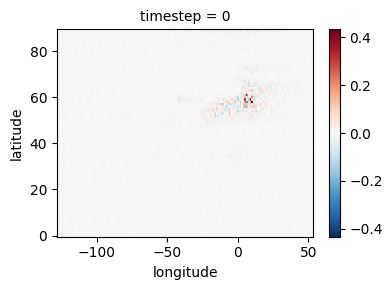

In [117]:
from captum.attr import IntegratedGradients
from captum.attr import Saliency
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import Occlusion
from captum.attr import LRP

# method = IntegratedGradients(lightning_model.model)
method = DeepLift(lightning_model.model)

ds_test_extract = ds_aligned.sel(time=['2011-11-26'])
# print(start,end)
# ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
tensor_in = torch.Tensor(ds_test_extract.features.values)
tensor_out = torch.Tensor(ds_test_extract.targets.values)
# attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
with torch.no_grad():
    attrs = method.attribute(tensor_in,target=7) 
da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                        coords= dict(timestep=[0],var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
sens = da_attrs/ds_test_extract.features.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)

da_attrs.plot(col='timestep')
# plt.figure()
# ds_test_extract.isel(timestep=0).features.plot()

In [94]:

layers = list(model._modules["features"]) + list(model._modules["classifier"])
num_layers = len(layers)

for idx_layer in range(1, num_layers):
    if idx_layer <= 16:
        setattr(layers[idx_layer], "rule", GammaRule())
    elif 17 <= idx_layer <= 30:
        setattr(layers[idx_layer], "rule", EpsilonRule())
    elif idx_layer >= 31:
        setattr(layers[idx_layer], "rule", EpsilonRule(epsilon=0))

lrp = LRP(model)
attributions_lrp = lrp.attribute(input, 
                                target=pred_label_idx)



KeyError: 'features'